# Notebook para análise exploratória dos dados unificados

## Dataframe antes da limpeza:

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Define o path do CSV unificado
script_dir = Path.cwd()
data_dir = script_dir.parent / "data"
csv_path = data_dir / "unified_dataframe.csv"

<class 'pandas.DataFrame'>
DatetimeIndex: 3653 entries, 2016-01-01 to 2025-12-31
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BTC_Open                      3653 non-null   float64
 1   BTC_High                      3653 non-null   float64
 2   BTC_Low                       3653 non-null   float64
 3   BTC_Close                     3653 non-null   float64
 4   BTC_Volume                    3653 non-null   int64  
 5   US_FEDFUNDS                   3653 non-null   float64
 6   US_FEDFUNDS_DAILY             3653 non-null   float64
 7   US_CPI                        3653 non-null   float64
 8   US_10Y                        3650 non-null   float64
 9   ECB_MAIN_REFINANCING          3653 non-null   float64
 10  GERMANY_CPI                   3653 non-null   float64
 11  FRANCE_CPI                    3653 non-null   float64
 12  ITALY_CPI                     3653 non-null   float64
 

,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,US_FEDFUNDS,US_FEDFUNDS_DAILY,US_CPI,US_10Y,ECB_MAIN_REFINANCING,...,USD_JPY,USD_CNY,NIFTY_50,IBOVESPA,USD_BRL,USD_ZAR,UK_POLICY_RATE,CANADA_POLICY_RATE,BRAZIL_SELIC,CANADA_CPI
count,3653.000000,3653.000000,3653.000000,3653.000000,3.653000e+03,3653.000000,3653.000000,3653.000000,3650.000000,3653.000000,...,3653.000000,3653.000000,3650.000000,3650.000000,3653.000000,3653.000000,3650.000000,3653.000000,3653.000000,3653.000000
mean,30249.572502,30858.827935,29606.180590,30272.254452,2.441560e+10,2.191528,2.190942,275.501279,2.697263,1.093964,...,122.989730,6.844391,15122.876273,100997.699178,4.594266,15.777577,1.789301,1.908842,9.557419,144.018834
std,32057.275563,32597.029482,31481.900581,32066.790421,2.287680e+10,1.907198,1.909834,28.892672,1.173855,1.647830,...,18.067245,0.293810,5625.048792,26380.946413,0.909113,2.040200,1.973974,1.632782,4.184667,12.637121
min,365.072998,374.950012,354.914001,364.330994,2.851400e+07,0.050000,0.040000,237.336000,0.520000,0.000000,...,99.905998,6.267600,6970.600098,37497.000000,3.056100,11.563800,0.100000,0.250000,2.000000,126.800000
25%,6413.629883,6535.410156,6316.879883,6416.314941,5.302482e+09,0.380000,0.370000,251.214000,1.740000,0.000000,...,109.080002,6.585400,10472.500000,79646.000000,3.750400,14.180800,0.250000,0.500000,6.500000,133.500000
50%,17128.894531,17567.699219,16812.369141,17130.486328,2.049660e+10,1.690000,1.690000,262.045000,2.550000,0.000000,...,112.875000,6.877500,13902.899902,105515.000000,4.953800,15.297390,0.750000,1.500000,10.500000,137.700000
75%,46415.898438,47510.726562,45235.816406,46453.566406,3.557456e+10,4.330000,4.330000,304.609000,3.860000,2.150000,...,142.772995,7.108500,19047.250000,120171.500000,5.360600,17.725130,4.000000,3.000000,13.750000,158.100000
max,124752.140625,126198.070312,123196.046875,124752.531250,3.509679e+11,5.330000,5.330000,326.031000,4.980000,4.500000,...,161.621002,7.350000,26216.050781,164456.000000,6.300000,19.774500,5.250000,5.000000,15.000000,165.400000



Dias duplicados no índice: 0
Colunas com valores constantes: []


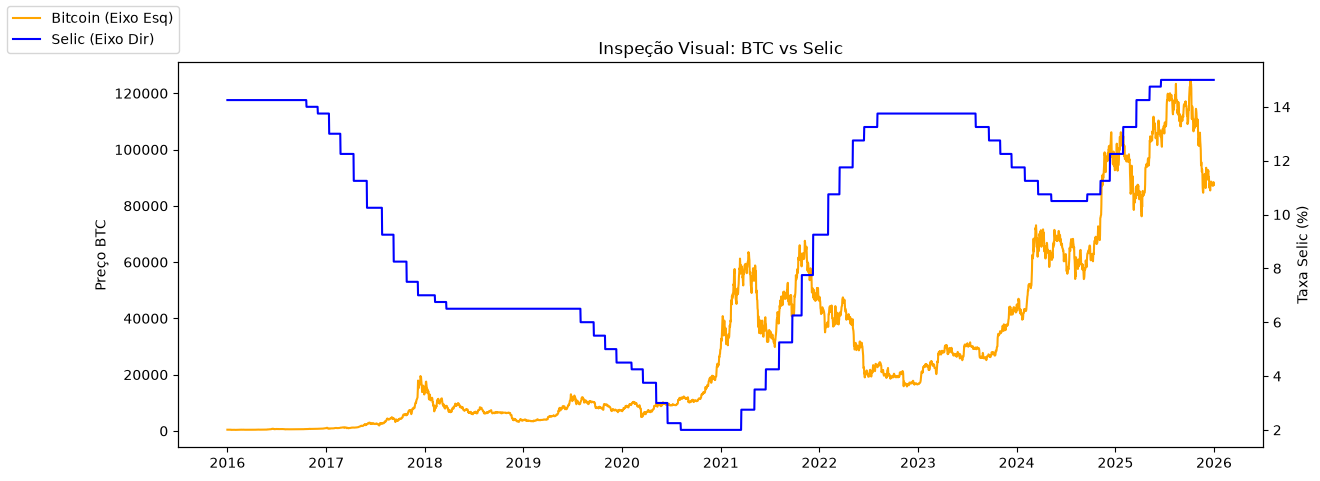

In [5]:
# Carrega o dataset 
df = pd.read_csv(csv_path, index_col="Date", parse_dates=True)

# Visão geral dos tipos de dados (tudo deve ser float ou int)
print(df.info())

# Resumo estatístico (olhe para os valores 'min' e 'max' para achar absurdos)
display(df.describe())

# Verifica se há dias duplicados no índice
duplicados = df.index.duplicated().sum()
print(f"\nDias duplicados no índice: {duplicados}")

# Verifica colunas que ficaram com variância zero (ficaram constantes)
constantes = [col for col in df.columns if df[col].nunique() == 1]
print(f"Colunas com valores constantes: {constantes}")

# Plota algumas variáveis para inspeção visual (ex: Bitcoin vs Selic)
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df.index, df['BTC_Close'], color='orange', label='Bitcoin (Eixo Esq)')
ax1.set_ylabel('Preço BTC')

ax2 = ax1.twinx()
ax2.plot(df.index, df['BRAZIL_SELIC'], color='blue', label='Selic (Eixo Dir)')
ax2.set_ylabel('Taxa Selic (%)')

fig.legend(loc="upper left")
plt.title("Inspeção Visual: BTC vs Selic")
plt.show()

In [6]:
summary_df = pd.DataFrame({
    "coluna": df.columns,
    "min": df.min().values,
    "max": df.max().values
})

display(summary_df)

,coluna,min,max
0,BTC_Open,3.650730e+02,1.247521e+05
1,BTC_High,3.749500e+02,1.261981e+05
2,BTC_Low,3.549140e+02,1.231960e+05
3,BTC_Close,3.643310e+02,1.247525e+05
4,BTC_Volume,2.851400e+07,3.509679e+11
5,US_FEDFUNDS,5.000000e-02,5.330000e+00
6,US_FEDFUNDS_DAILY,4.000000e-02,5.330000e+00
7,US_CPI,2.373360e+02,3.260310e+02
8,US_10Y,5.200000e-01,4.980000e+00
9,ECB_MAIN_REFINANCING,0.000000e+00,4.500000e+00


In [8]:
# Total e Percentual de Nulos por Coluna
nulos_resumo = pd.DataFrame({
    'Total Nulos': df.isna().sum(),
    'Percentual (%)': (df.isna().sum() / len(df)) * 100
})
# Filtra apenas as colunas que têm algum nulo
nulos_resumo = nulos_resumo[nulos_resumo['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)
print("--- RESUMO DE VALORES NULOS ---")
display(nulos_resumo)

# Onde esses nulos estão? (Identificando as datas problemáticas)
linhas_com_nulos = df[df.isna().any(axis=1)]
print(f"\nTotal de linhas afetadas por nulos: {len(linhas_com_nulos)}")
print("\nPrimeiras datas com nulos (Geralmente 2016):")
display(linhas_com_nulos.head())
print("\nÚltimas datas com nulos (Geralmente datas recentes):")
display(linhas_com_nulos.tail())

display(df)

--- RESUMO DE VALORES NULOS ---


,Total Nulos,Percentual (%)
US_10Y,3,0.082124
US_DXY,3,0.082124
NASDAQ_100,3,0.082124
DAX,3,0.082124
CAC_40,3,0.082124
FTSE_MIB,3,0.082124
FTSE_100,3,0.082124
SP_TSX,3,0.082124
NIKKEI_225,3,0.082124
NIFTY_50,3,0.082124



Total de linhas afetadas por nulos: 3

Primeiras datas com nulos (Geralmente 2016):


,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,US_FEDFUNDS,US_FEDFUNDS_DAILY,US_CPI,US_10Y,ECB_MAIN_REFINANCING,...,USD_JPY,USD_CNY,NIFTY_50,IBOVESPA,USD_BRL,USD_ZAR,UK_POLICY_RATE,CANADA_POLICY_RATE,BRAZIL_SELIC,CANADA_CPI
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,430.721008,436.246002,427.515015,434.334015,36278900,0.34,0.2,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.95,15.46,NaN,0.5,14.25,126.8
2016-01-02,434.622009,436.062012,431.869995,433.437988,30096600,0.34,0.2,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.95,15.46,NaN,0.5,14.25,126.8
2016-01-03,433.578003,433.743011,424.705994,430.010986,39633800,0.34,0.2,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.95,15.46,NaN,0.5,14.25,126.8



Últimas datas com nulos (Geralmente datas recentes):


,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,US_FEDFUNDS,US_FEDFUNDS_DAILY,US_CPI,US_10Y,ECB_MAIN_REFINANCING,...,USD_JPY,USD_CNY,NIFTY_50,IBOVESPA,USD_BRL,USD_ZAR,UK_POLICY_RATE,CANADA_POLICY_RATE,BRAZIL_SELIC,CANADA_CPI
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,430.721008,436.246002,427.515015,434.334015,36278900,0.34,0.2,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.95,15.46,NaN,0.5,14.25,126.8
2016-01-02,434.622009,436.062012,431.869995,433.437988,30096600,0.34,0.2,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.95,15.46,NaN,0.5,14.25,126.8
2016-01-03,433.578003,433.743011,424.705994,430.010986,39633800,0.34,0.2,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.95,15.46,NaN,0.5,14.25,126.8


,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,US_FEDFUNDS,US_FEDFUNDS_DAILY,US_CPI,US_10Y,ECB_MAIN_REFINANCING,...,USD_JPY,USD_CNY,NIFTY_50,IBOVESPA,USD_BRL,USD_ZAR,UK_POLICY_RATE,CANADA_POLICY_RATE,BRAZIL_SELIC,CANADA_CPI
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,430.721008,436.246002,427.515015,434.334015,36278900,0.34,0.20,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.9500,15.460000,NaN,0.50,14.25,126.8
2016-01-02,434.622009,436.062012,431.869995,433.437988,30096600,0.34,0.20,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.9500,15.460000,NaN,0.50,14.25,126.8
2016-01-03,433.578003,433.743011,424.705994,430.010986,39633800,0.34,0.20,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.9500,15.460000,NaN,0.50,14.25,126.8
2016-01-04,430.061005,434.516998,429.084015,433.091003,38477500,0.34,0.36,237.652,2.24,0.05,...,120.310997,6.4837,7791.299805,42141.0,3.9491,15.460640,0.50,0.50,14.25,126.8
2016-01-05,433.069000,434.182007,429.675995,431.959991,34522600,0.34,0.36,237.652,2.25,0.05,...,119.467003,6.5254,7784.649902,42419.0,4.0373,15.523000,0.50,0.50,14.25,126.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,87301.429688,87874.781250,87182.976562,87802.156250,13741199310,3.72,3.64,326.031,4.14,2.15,...,156.089996,7.0280,26042.300781,160897.0,5.5195,16.627199,3.75,2.25,15.00,165.0
2025-12-28,87799.343750,87986.890625,87394.953125,87835.835938,15156557929,3.72,3.64,326.031,4.14,2.15,...,156.089996,7.0280,26042.300781,160897.0,5.5195,16.627199,3.75,2.25,15.00,165.0
2025-12-29,87835.789062,90299.156250,86717.914062,87138.140625,48411625849,3.72,3.64,326.031,4.12,2.15,...,156.462997,7.0280,25942.099609,160490.0,5.5425,16.659201,3.75,2.25,15.00,165.0


## Análise exploratória do dataframe clean

#### Baixando o dataframe clean da nuvem (HuggingFace) - caso necessário

In [9]:
from datasets import load_dataset
import pandas as pd

def download_from_huggingface():
    """
    Baixa o dataset financeiro do Hugging Face e 
    formata para o padrão Pandas (DatetimeIndex).
    """

    repo_id = "leodemore/btc-finance-historical-data"
    print(f"Baixando dados de: {repo_id}...")

    # Baixa o dataset do Hub
    dataset = load_dataset(repo_id)
    
    # Converte para um DataFrame do Pandas
    df = dataset['train'].to_pandas()
    
    # Restaura o formato original da coluna de Data
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    
    print("Download concluído! Dimensões do dataset:", df.shape)
    
    return df

/home/leodemore/GitHub/MADES/MADES/sources/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Análise exploratória

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df = download_from_huggingface()
display(df)

Baixando dados de: leodemore/btc-finance-historical-data...


Generating train split: 100%|██████████| 3650/3650 [00:00<00:00, 44336.22 examples/s]

Download concluído! Dimensões do dataset: (3650, 45)


,index,Unnamed: 0,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,US_FEDFUNDS,US_FEDFUNDS_DAILY,US_CPI,...,USD_JPY,USD_CNY,NIFTY_50,IBOVESPA,USD_BRL,USD_ZAR,UK_POLICY_RATE,CANADA_POLICY_RATE,BRAZIL_SELIC,CANADA_CPI
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,0,3,430.061005,434.516998,429.084015,433.091003,38477500,0.34,0.36,237.652,...,120.310997,6.4837,7791.299805,42141.0,3.9491,15.460640,0.50,0.50,14.25,126.8
2016-01-05,1,4,433.069000,434.182007,429.675995,431.959991,34522600,0.34,0.36,237.652,...,119.467003,6.5254,7784.649902,42419.0,4.0373,15.523000,0.50,0.50,14.25,126.8
2016-01-06,2,5,431.855988,431.855988,426.341003,429.105011,34042500,0.34,0.36,237.652,...,119.101997,6.5125,7741.000000,41773.0,4.0269,15.637650,0.50,0.50,14.25,126.8
2016-01-07,3,6,430.010986,458.765991,429.076996,458.048004,87562200,0.34,0.36,237.652,...,118.610001,6.5467,7568.299805,40695.0,4.0199,15.857880,0.50,0.50,14.25,126.8
2016-01-08,4,7,457.537994,462.933990,447.937988,453.230011,56993000,0.34,0.36,237.652,...,117.540001,6.5829,7601.350098,40612.0,4.0415,16.058680,0.50,0.50,14.25,126.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,3645,3648,87301.429688,87874.781250,87182.976562,87802.156250,13741199310,3.72,3.64,326.031,...,156.089996,7.0280,26042.300781,160897.0,5.5195,16.627199,3.75,2.25,15.00,165.0
2025-12-28,3646,3649,87799.343750,87986.890625,87394.953125,87835.835938,15156557929,3.72,3.64,326.031,...,156.089996,7.0280,26042.300781,160897.0,5.5195,16.627199,3.75,2.25,15.00,165.0
2025-12-29,3647,3650,87835.789062,90299.156250,86717.914062,87138.140625,48411625849,3.72,3.64,326.031,...,156.462997,7.0280,25942.099609,160490.0,5.5425,16.659201,3.75,2.25,15.00,165.0
